<div style="color: white; text-align: center; font-size: 30px;">
<strong> EJERCICIO DE GRUPO 2 </strong>
</div> 
<div style="color: white; text-align: center; font-size: 20px;">
<strong> Maestría en Ciberseguridad </strong>
</div> 
<div>
<strong> GRUPO 2 </strong>
</div>
Edison Molina <br>
Kevin Avalos <br>
Alexander Lara <br>
Merci León <br>
Jorge Mena 



Como primer paso se importan las librerías necesarias para este ejercicio.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from random import randrange
import datetime
from scipy.stats import norm

# Cargar el dataset
df = pd.read_csv('cybersecurity_intrusion_data.csv')


# Mostrar el total de eventos registrados
total_eventos = len(df)
print(f"Total de eventos registrados: {total_eventos}")
# Es importante en el analisis de datos, para ello evaluamos cuales son los puertos mas usados  
# Calcular el porcentaje de uso de los puertos
# Primero, verifiquemos los tipos de protocolo (puerto).
porcentaje_protocolos = df['protocol_type'].value_counts(normalize=True) * 100
print("\nPorcentaje de uso de los puertos:")
print(porcentaje_protocolos)

# Calcular el porcentaje de navegadores usados
porcentaje_navegadores = df['browser_type'].value_counts(normalize=True) * 100
print("\nPorcentaje de navegadores usados:")
print(porcentaje_navegadores)

Total de eventos registrados: 9537

Porcentaje de uso de los puertos:
protocol_type
TCP     69.455804
UDP     25.228059
ICMP     5.316137
Name: proportion, dtype: float64

Porcentaje de navegadores usados:
browser_type
Chrome     53.863899
Firefox    20.383768
Edge       15.403167
Unknown     5.263710
Safari      5.085457
Name: proportion, dtype: float64


Para el usuario es importante interpretar los datos de manera correcta y los mas intuitiva posible, para lo cual se elabora el siguinte gráfico, donde se tiene los porcentajes anterior mostrados en un diagrama mas ilustrativo

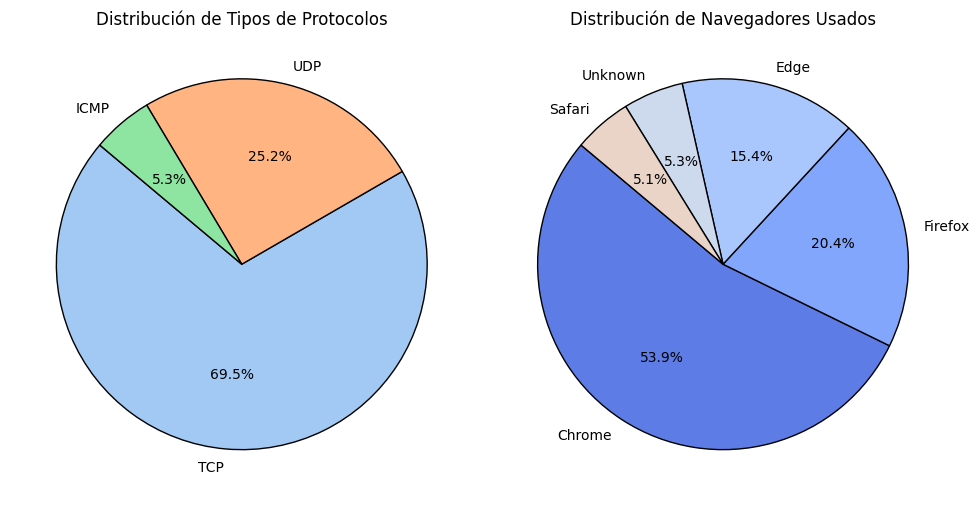

In [5]:
# Configuración de colores
colors1 = sns.color_palette("pastel")  # Colores para el gráfico de protocolos
colors2 = sns.color_palette("coolwarm", 8)  # Colores para el gráfico de navegadores

# Gráfico de pastel para protocolos usados
protocol_counts = df["protocol_type"].value_counts()

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.pie(protocol_counts, labels=protocol_counts.index, autopct='%1.1f%%', colors=colors1, startangle=140, wedgeprops={'edgecolor': 'black'})
plt.title("Distribución de Tipos de Protocolos")

# Gráfico de pastel para navegadores más usados
browser_counts = df["browser_type"].value_counts()

plt.subplot(1, 2, 2)
plt.pie(browser_counts, labels=browser_counts.index, autopct='%1.1f%%', colors=colors2, startangle=140, wedgeprops={'edgecolor': 'black'})
plt.title("Distribución de Navegadores Usados")

# Mostrar gráficos
plt.tight_layout()
plt.show()

Vamos a validar que los datos esten correctos, sin embargo debido a la naturaleza del DATASET encontrado, no tenemos registro de hora y fecha.

In [2]:
print(df)

     session_id  network_packet_size protocol_type  login_attempts  \
0     SID_00001                  599           TCP               4   
1     SID_00002                  472           TCP               3   
2     SID_00003                  629           TCP               3   
3     SID_00004                  804           UDP               4   
4     SID_00005                  453           TCP               5   
...         ...                  ...           ...             ...   
9532  SID_09533                  194          ICMP               3   
9533  SID_09534                  380           TCP               3   
9534  SID_09535                  664           TCP               5   
9535  SID_09536                  406           TCP               4   
9536  SID_09537                  340           TCP               6   

      session_duration encryption_used  ip_reputation_score  failed_logins  \
0           492.983263             DES             0.606818              1   
1  

Vamos a crear dos funciones que nos permitan crear las columnas fecha y hora. (Para un analisis correcto no se pueden inventar datos, sin embargo se añaden para darle mas profundidad a los datos encontrados)

In [6]:
# Función para generar fechas aleatorias entre 2022 y 2025
def generar_fecha_aleatoria():
    # Generar año entre 2022 y 2025
    año = randrange(2022, 2026)
    # Generar mes entre 1 y 12
    mes = randrange(1, 13)
    # Generar día entre 1 y 28 (para evitar problemas con días de mes)
    dia = randrange(1, 29)
    return datetime.date(año, mes, dia)

# Función para generar horas aleatorias (en formato HH:MM:SS)
def generar_hora_aleatoria():
    # Generar hora, minuto y segundo aleatorios
    hora = randrange(0, 24)
    minuto = randrange(0, 60)
    segundo = randrange(0, 60)
    return f"{hora:02}:{minuto:02}:{segundo:02}"

# Crear las nuevas columnas con fechas y horas aleatorias
df['fecha'] = [generar_fecha_aleatoria() for _ in range(len(df))]
df['hora'] = [generar_hora_aleatoria() for _ in range(len(df))]

# Mostrar las primeras filas del dataframe con las nuevas columnas
print(df.head())

  session_id  network_packet_size protocol_type  login_attempts  \
0  SID_00001                  599           TCP               4   
1  SID_00002                  472           TCP               3   
2  SID_00003                  629           TCP               3   
3  SID_00004                  804           UDP               4   
4  SID_00005                  453           TCP               5   

   session_duration encryption_used  ip_reputation_score  failed_logins  \
0        492.983263             DES             0.606818              1   
1       1557.996461             DES             0.301569              0   
2         75.044262             DES             0.739164              2   
3        601.248835             DES             0.123267              0   
4        532.540888             AES             0.054874              1   

  browser_type  unusual_time_access  attack_detected       fecha      hora  
0         Edge                    0                1  2024-03-28  20:

In [ ]:
print(df.head())
# Comprobamos nuevamente si se esta creando correctamente

  session_id  network_packet_size protocol_type  login_attempts  \
0  SID_00001                  599           TCP               4   
1  SID_00002                  472           TCP               3   
2  SID_00003                  629           TCP               3   
3  SID_00004                  804           UDP               4   
4  SID_00005                  453           TCP               5   

   session_duration encryption_used  ip_reputation_score  failed_logins  \
0        492.983263             DES             0.606818              1   
1       1557.996461             DES             0.301569              0   
2         75.044262             DES             0.739164              2   
3        601.248835             DES             0.123267              0   
4        532.540888             AES             0.054874              1   

  browser_type  unusual_time_access  attack_detected       fecha      hora  
0         Edge                    0                1  2025-10-06  11:

Validamos que la columna fecha sea tomada como una fecha.
<div style="color: white; text-align: center; font-size: 20px;">
<strong> MAPA DE CALOR</strong>
</div> 
<div>
<strong> ANALISIS </strong>
</div>
Este diagrama nos va a servir en mayor medida a analizar patrones basado en el horario o en los días, si bien es cierto los datos son creados y aleatorios, el correcto analísis de estos datos en realidad, nos puede indiciar en que momento del dia somos mas vulnerables. 

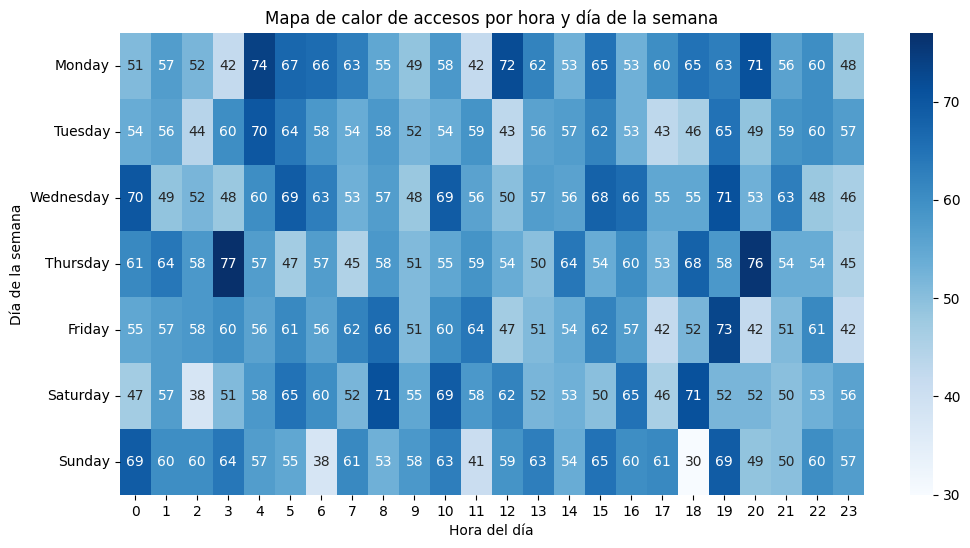

In [7]:
# Convertir la columna 'fecha' a tipo datetime
df['fecha'] = pd.to_datetime(df['fecha'])

# Extraer día de la semana y hora
df['dia_semana'] = df['fecha'].dt.day_name()  # Lunes, Martes, etc.
df['hora'] = pd.to_datetime(df['hora'], format="%H:%M:%S").dt.hour  # Solo extraer la hora

# Crear una tabla pivote con la cantidad de accesos por día y hora
heatmap_data = df.pivot_table(index="dia_semana", columns="hora", aggfunc="size", fill_value=0)

# Reordenar los días de la semana en orden lógico
dias_ordenados = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
heatmap_data = heatmap_data.reindex(dias_ordenados)

# Crear el mapa de calor
plt.figure(figsize=(12, 6))
sns.heatmap(heatmap_data, cmap="Blues", annot=True, fmt="d")

# Configurar etiquetas y título
plt.title("Mapa de calor de accesos por hora y día de la semana")
plt.xlabel("Hora del día")
plt.ylabel("Día de la semana")

# Mostrar el gráfico
plt.show()

<strong> HISTOGRAMA</strong>
</div> 
<div>
<strong> ANALISIS </strong>
</div>
Podemos analizar el comportamiento de los usuarios, relacionando su tiempo de conexion y el total de eventos ocurridos con similares caracteristicas <br>
Los usuarios reales pueden tener un tiempo de conexion dentro de un rango esperado, sin embargo conexiones muy cortas o muy largas pueden indicar inconvenientes.

Media del tiempo de sesión: 792.75 segundos
Desviación estándar: 786.56 segundos


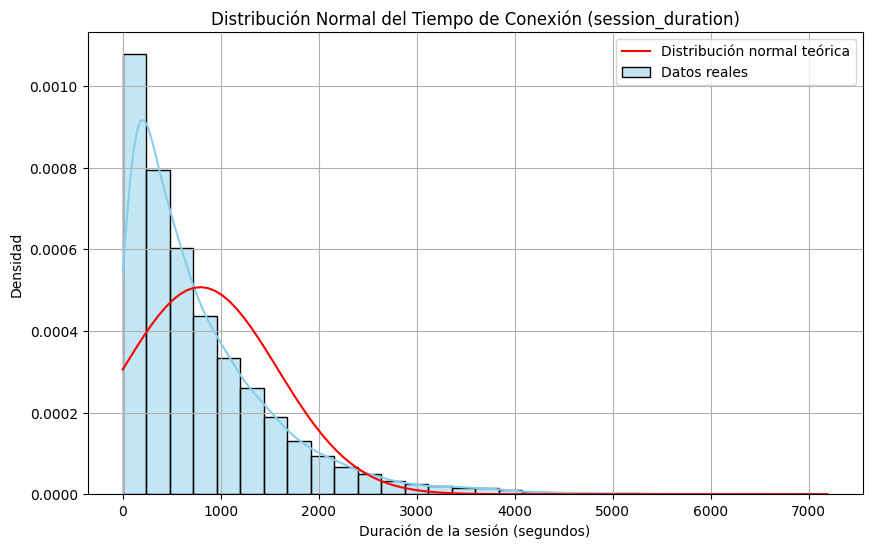

In [8]:
df['session_duration'] = pd.to_numeric(df['session_duration'], errors='coerce')
df = df.dropna(subset=['session_duration'])  # Eliminar posibles valores nulos

# Calcular media y desviación estándar
media = df['session_duration'].mean()
desviacion = df['session_duration'].std()

print(f"Media del tiempo de sesión: {media:.2f} segundos")
print(f"Desviación estándar: {desviacion:.2f} segundos")

# Crear histograma con curva de distribución normal
plt.figure(figsize=(10, 6))
sns.histplot(df['session_duration'], kde=True, bins=30, stat="density", color="skyblue", label="Datos reales")

# Crear una curva de distribución normal teórica
x = np.linspace(df['session_duration'].min(), df['session_duration'].max(), 100)
y = norm.pdf(x, media, desviacion)
plt.plot(x, y, 'r', label="Distribución normal teórica")

# Configuración del gráfico
plt.title("Distribución Normal del Tiempo de Conexión (session_duration)")
plt.xlabel("Duración de la sesión (segundos)")
plt.ylabel("Densidad")
plt.legend()
plt.grid(True)

# Mostrar el gráfico
plt.show()

<strong> IDENTIFICACIÓN DE IP</strong>
</div> 
<div>
<strong> UMBRAL DE 0.5 </strong>
</div>
Los datos nos indican un score en las IP que se conectan, por eso definimos que un score mayor a 0.5 signigica que es una IP segura y si es igual o menor es una ip insegura.

In [9]:
df['ip_segura'] = df['ip_reputation_score'] > 0.5

# Crear tabla de resumen
resumen_ips = df.groupby('ip_segura').agg(
    intentos_fallidos=('failed_logins', 'sum'),
    total_sesiones=('session_id', 'count')
).reset_index()

# Renombrar valores para claridad
resumen_ips['ip_segura'] = resumen_ips['ip_segura'].map({True: "Segura (>0.5)", False: "No Segura (≤0.5)"})

# Mostrar tabla
print(resumen_ips)

          ip_segura  intentos_fallidos  total_sesiones
0  No Segura (≤0.5)              11729            7763
1     Segura (>0.5)               2746            1774


De acuerdo a los valores encontrados, vamos a crear un diagrama de pastel indicando el porcentaje de IPs seguras, de acuerdo a su score.

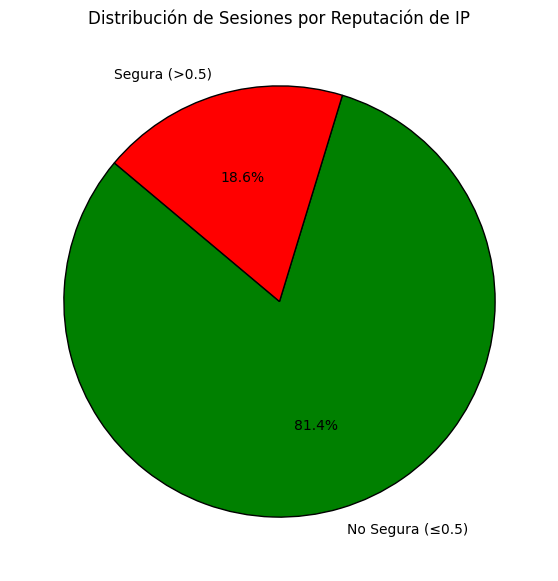

In [10]:
labels = resumen_ips['ip_segura']
sizes = resumen_ips['total_sesiones']
colors = ["green", "red"]  # Verde para seguras, rojo para no seguras

# Crear el gráfico de pastel
plt.figure(figsize=(7, 7))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', colors=colors, startangle=140, wedgeprops={'edgecolor': 'black'})

# Configuración del gráfico
plt.title("Distribución de Sesiones por Reputación de IP")
plt.show()

<strong> BARRAS</strong>
</div> 
<div>
<strong> ANALISIS </strong>
</div>
El diagrama muestra cual es el navegador mas utilizado

/tmp/ipykernel_61369/2812898504.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=browser_counts.index, y=browser_counts.values, palette="coolwarm")


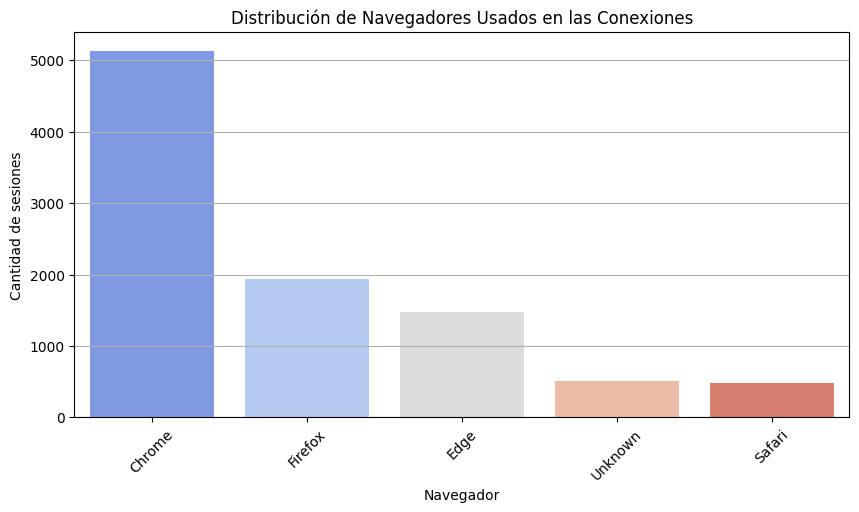

In [13]:
# Contar la cantidad de sesiones por navegador
browser_counts = df["browser_type"].value_counts()

# Crear gráfico de barras
plt.figure(figsize=(10, 5))
sns.barplot(x=browser_counts.index, y=browser_counts.values, palette="coolwarm")

# Configurar etiquetas
plt.title("Distribución de Navegadores Usados en las Conexiones")
plt.xlabel("Navegador")
plt.ylabel("Cantidad de sesiones")
plt.xticks(rotation=45)  # Rotar etiquetas si son muchas
plt.grid(axis='y')

# Mostrar el gráfico
plt.show()

<strong> ANÁLISIS</strong>
</div> 
<div>
<strong> NAVEGADOR DESCONOCIDO</strong>
</div>

Si se busca hacer un analisis profundo de los datos, podriamos pensar que un navegador desconocido puede ser una fuente de peligro, en la cual vamos a analizar, que puerto utiliza mas.

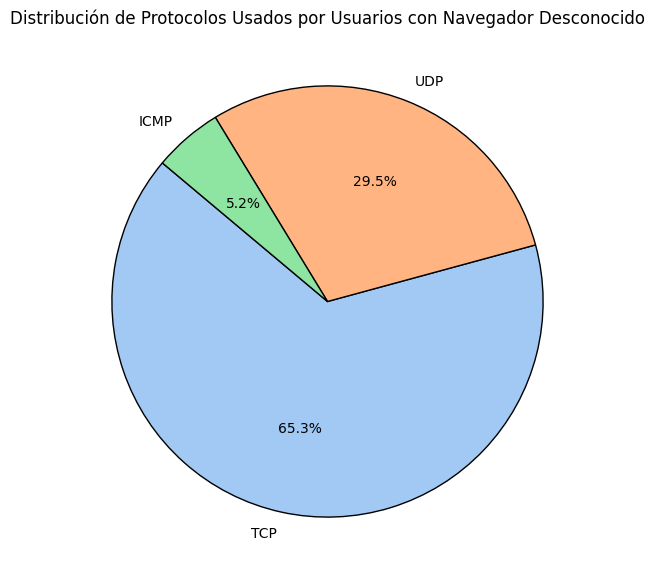

In [14]:
# Filtrar solo los usuarios con navegador "Unknown"
df_unknown = df[df["browser_type"] == "Unknown"]

# Contar la cantidad de sesiones por protocolo
protocol_counts = df_unknown["protocol_type"].value_counts()

# Crear gráfico de pastel
plt.figure(figsize=(7, 7))
plt.pie(protocol_counts, labels=protocol_counts.index, autopct='%1.1f%%', 
        colors=sns.color_palette("pastel", len(protocol_counts)), startangle=140, wedgeprops={'edgecolor': 'black'})

# Configuración del gráfico
plt.title("Distribución de Protocolos Usados por Usuarios con Navegador Desconocido")
plt.show()

UDP, podría ser un intento de ataque DDoS.
TCP sospechosos, puede indicar exploración de puertos o intentos de acceso no autorizados.

De esta manera analizamos si existe algun inconveniente 